**Labolatorium 05 - zbiory rozmyte**

*Kocjan Nikodem*

Wymagane importy

In [1]:
!pip install scikit-fuzzy
import numpy as np
import matplotlib.pyplot as plt
import skfuzzy as fuzz
from skfuzzy import control as ctrl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 24.8 MB/s eta 0:00:00


**Zadanie 1**

W celu dokonania badań na zbiorach rozmytych wykorzystano bibliotekę skfuzzy i to jej metody będą pojawiały się w tym sprawozdaniu najczęściej.
Do wykonania zadania 1 potrzebne są trzy zmienne
- temperatura ->  wejście z zakresu do 15 do 36 stopni z krokiem 1 stopień
- wilgotność -> wejście z zakresu od 0 do 100 procent z krokiem co 1 procent
- woda -> wyjście jako ilość wody generowana przez system podlewania z zakresu od 0 do 26 litrów dziennie

In [2]:
temp = ctrl.Antecedent(np.arange(15, 36, 1), 'temperatura')
wilgotnosc = ctrl.Antecedent(np.arange(0, 101, 1), 'wilgotnosc')
woda = ctrl.Consequent(np.arange(0, 26, 1), 'ilosc_wody')

Kolejnym krokiem będzie przygotowanie funkcji przynależności dla zmiennych

Dla temperatury określono funkcję przynależności do zbiorów chłodno, ciepło, gorąco. Zakładamy chłodno od 15 do 23 z pełną przynależnością dla 15. Ciepło w zakresie od 20 do 28 z pełną przynależnością dla 24. Gorąco od 25 do 35 z pełną przynależnością dla 35

In [3]:
temp['chlodno'] = fuzz.trimf(temp.universe, [15, 15, 23])
temp['cieplo'] = fuzz.trimf(temp.universe, [20, 24, 28])
temp['goraco'] = fuzz.trimf(temp.universe, [25, 35, 35])

Dla wilgotności określono funkcję przynależności do zbiorów sucho, przecietnie, mokro. Zakładamy sucho od 0 do 40 z pełną przynależnością dla 0. Przecietnie w zakresie od 25 do 75 z pełną przynależnością dla 50. Mokro od 60 do 100 z pełną przynależnością dla 100

In [4]:
wilgotnosc['sucho'] = fuzz.trimf(wilgotnosc.universe, [0, 0, 40])
wilgotnosc['przecietnie'] = fuzz.trimf(wilgotnosc.universe, [25, 50, 75])
wilgotnosc['mokro'] = fuzz.trimf(wilgotnosc.universe, [60, 100, 100])

Dla wilgotności określono funkcję przynależności do zbiorów malo, srednio, duzo. Zakładamy malo od 0 do 10 z pełną przynależnością dla 0. Srednio w zakresie od 5 do 18 z pełną przynależnością dla 10. Duzo od 15 do 25 z pełną przynależnością dla 25.

In [5]:
woda['malo'] = fuzz.trimf(woda.universe, [0, 0, 10])
woda['srednio'] = fuzz.trimf(woda.universe, [5, 10, 18])
woda['duzo'] = fuzz.trimf(woda.universe, [15, 25, 25])

Na podstawie tabelki z polecenia uzupełniono zasady dla wody, zależnie od temperatury i wilgotności.

In [6]:
rule1 = ctrl.Rule(temp['chlodno'] & wilgotnosc['sucho'], woda['srednio'])
rule2 = ctrl.Rule(temp['chlodno'] & wilgotnosc['przecietnie'], woda['srednio'])
rule3 = ctrl.Rule(temp['chlodno'] & wilgotnosc['mokro'], woda['malo'])
rule4 = ctrl.Rule(temp['cieplo'] & wilgotnosc['sucho'], woda['duzo'])
rule5 = ctrl.Rule(temp['cieplo'] & wilgotnosc['przecietnie'], woda['srednio'])
rule6 = ctrl.Rule(temp['cieplo'] & wilgotnosc['mokro'], woda['malo'])
rule7 = ctrl.Rule(temp['goraco'] & wilgotnosc['sucho'], woda['duzo'])
rule8 = ctrl.Rule(temp['goraco'] & wilgotnosc['przecietnie'], woda['duzo'])
rule9 = ctrl.Rule(temp['goraco'] & wilgotnosc['mokro'], woda['srednio'])

Na podstawie regul oraz zaleznosci przygotowano model rozmyty

In [7]:
nawadnianie = ctrl.ControlSystemSimulation(ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5, rule6, rule7, rule8, rule9]))

Przygotowano dane do symulacji oraz zwizualizowania rezultatow. W celu osiągnięcia kwadratowej heat mapy, ustawiono krok wilgotności co 5 procent.

In [8]:
wilgotnosc_range = np.arange(0, 101, 5)
temp_range = np.arange(15, 36, 1)
wyniki = np.zeros((len(temp_range), len(wilgotnosc_range)))

Dla temperatur oraz wilgotnosci z wcześniej zdefiniowanego zakresu wykonano badanie. Rezultat zostanie przedstawiony w formie heat mapy.

In [9]:
for i, t in enumerate(temp_range):
    for j, w in enumerate(wilgotnosc_range):
        nawadnianie.input['temperatura'] = t
        nawadnianie.input['wilgotnosc'] = w
        nawadnianie.compute()
        wyniki[i, j] = nawadnianie.output['ilosc_wody']

Generowania wyników

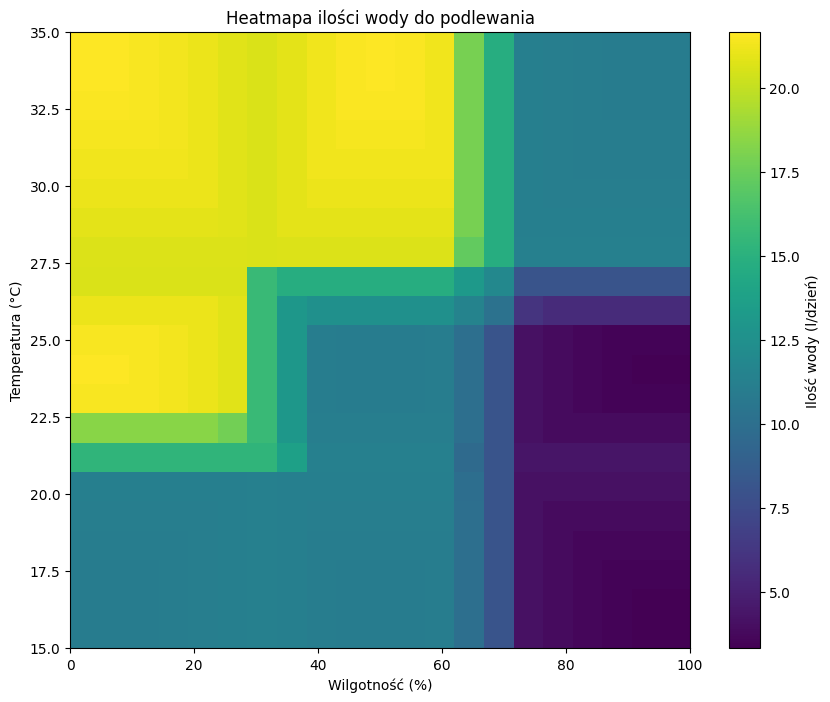

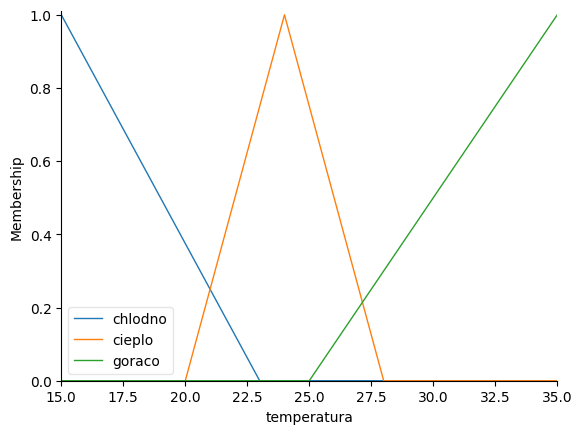

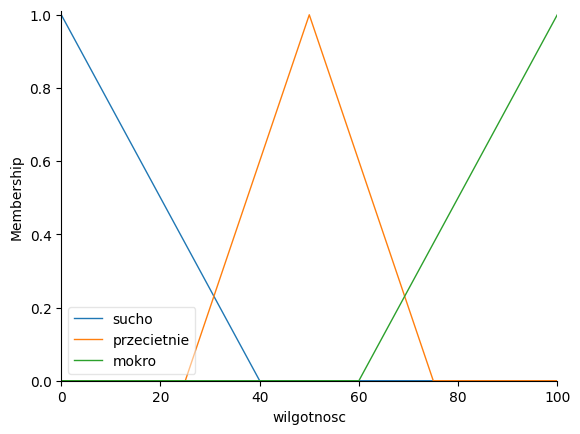

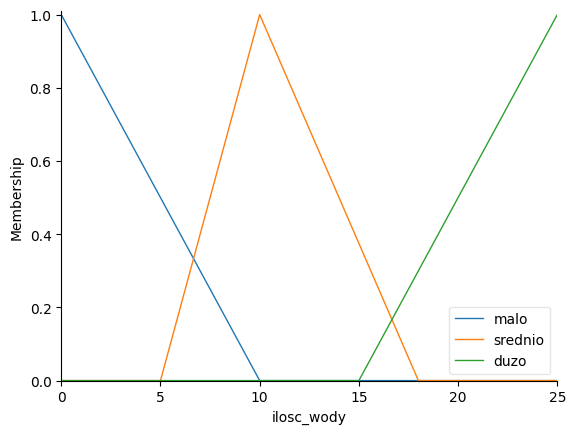

In [10]:
plt.figure(figsize=(10, 8))
plt.imshow(wyniki, cmap='viridis', extent=[0, 100, 15, 35], origin='lower', aspect='auto')
plt.colorbar(label='Ilość wody (l/dzień)')
plt.xlabel('Wilgotność (%)')
plt.ylabel('Temperatura (°C)')
plt.title('Heatmapa ilości wody do podlewania')
plt.show()

temp.view()
wilgotnosc.view()
woda.view()

Zadanie wykonano zgodnie z poleceń, rezultatem jest heatmapa obrazująca wymaganą iloścć litrów wody na podstawie wilgotności oraz temperatury. Odpowiednie dobranie funkcji przynależności, oraz zastosowanie reguł dla każdej możliwej opcji, pozwoliło na wygenerowanie heatmapy z płynnymi przejściami pomiędzy kolorami, co nie jest oczywiste, gdy popatrzymy na następne zadanie.

Można zauważyć, że największe wachania kolorów znajdują się tam, gdzie widoki najbardziej się wachały, tj. temperatura 21 stopni jest zarówno ciepła jak i chłodna, więc gdy zobaczymy na heatmapę, to w tym miejscu w następuje znaczące przejście między kolorami.

**Zadanie 2**

Celem badania jest propozycja dowolnego rozmytego systemu wnioskowania. Wymagane są trzy zmienne wejśicowe i każda z nich podzielona na conajmniej trzy zbiory rozmyte.

Opis wybranego zagadnienia:
System rozmyty mający na celu zaproponowanie dawki kofeiny dla osoby potrzebującej na podstawie:
- czas od ostatniego spożycia, bądź ostatniej sesji snu ( 0 - 24h )
- poziom zmęczenia ( skala 1 - 10 )
- ilość zaległych sprawozdań z MIO ( 0 - 5 )

Zbiór danych wyjściowych to zakres kofeiny od 0 do 200 mg z wyciągniętymi kategoriami:
- puszka dzik mango 0 kofeiny
- puszka red bull 250ml
- puszka red bull 330ml
- puszka dzik tropic 200mg kofeiny bomba

Zdefniowanie zbioru danych wejściowych oraz wyjściowych

In [28]:
czas = ctrl.Antecedent(np.arange(0, 25, 1), 'czas_od_spoczynku')
zmeczenie = ctrl.Antecedent(np.arange(1, 11, 1), 'poziom_zmeczenia')
sprawozdania = ctrl.Antecedent(np.arange(0, 6, 1), 'ilosc_sprawozdan')
kofeina = ctrl.Consequent(np.arange(0, 201, 1), 'kofeina')

Uzuppełnienie funkcji czasu na podstawie ilościu godzin od snu / dawki kofeiny. Założono, że po 8 godzinach od ostatniej kawy, bądź od obudzenia się, jest odpowiednia pora na dawkę kofeiny

In [29]:
czas['niedawno'] = fuzz.trimf(czas.universe, [0, 0, 12])
czas['srednio'] = fuzz.trimf(czas.universe, [6, 8, 20])
czas['dawno'] = fuzz.trimf(czas.universe, [12, 24, 24])

Funkcja zmęczenia jest mocno subiektywna, dlatego dane rozłożono symetrycznie. Skala ( 1 - 10 ) oznacza 1 -> brak zmęczenia, 10 -> duże zmęczenie.

In [30]:
zmeczenie['niskie'] = fuzz.trimf(zmeczenie.universe, [1, 1, 4])
zmeczenie['srednie'] = fuzz.trimf(zmeczenie.universe, [2, 5.5, 8])
zmeczenie['wysokie'] = fuzz.trimf(zmeczenie.universe, [7, 10, 10])

Funkcja ilości zaległych sprawozdań.

In [31]:
sprawozdania['brak'] = fuzz.trimf(sprawozdania.universe, [0, 0, 1])
sprawozdania['troche'] = fuzz.trimf(sprawozdania.universe, [1, 2, 4])
sprawozdania['duzo'] = fuzz.trimf(sprawozdania.universe, [3, 5, 5])

Wyniki kofeiny rozłożone zgodnie z kategoriami opisanymi na początku zadania.

In [32]:
kofeina['dzik_mango_0_kofeiny'] = fuzz.trimf(kofeina.universe, [0, 0, 50])
kofeina['redbull_250ml'] = fuzz.trimf(kofeina.universe, [25, 75, 125])
kofeina['redbull_330ml'] = fuzz.trimf(kofeina.universe, [100, 150, 175])
kofeina['dzik_tropic_200mg_kofeiny_bomba'] = fuzz.trimf(kofeina.universe, [150, 200, 200])

Zdefiniowanie zasad

In [33]:
rule1 = ctrl.Rule(zmeczenie['niskie'] & czas['niedawno'], kofeina['dzik_mango_0_kofeiny'])
rule2 = ctrl.Rule(zmeczenie['srednie'] & czas['niedawno'], kofeina['redbull_250ml'])
rule3 = ctrl.Rule(zmeczenie['wysokie'] & czas['niedawno'], kofeina['redbull_330ml'])

rule4 = ctrl.Rule(zmeczenie['niskie'] & czas['srednio'], kofeina['redbull_250ml'])
rule5 = ctrl.Rule(zmeczenie['srednie'] & czas['srednio'], kofeina['redbull_250ml'])
rule6 = ctrl.Rule(zmeczenie['wysokie'] & czas['srednio'], kofeina['dzik_tropic_200mg_kofeiny_bomba'])

rule7 = ctrl.Rule(zmeczenie['niskie'] & czas['dawno'], kofeina['redbull_250ml'])
rule8 = ctrl.Rule(zmeczenie['srednie'] & czas['dawno'], kofeina['redbull_330ml'])
rule9 = ctrl.Rule(zmeczenie['wysokie'] & czas['dawno'], kofeina['dzik_tropic_200mg_kofeiny_bomba'])

rule10 = ctrl.Rule(sprawozdania['duzo'], kofeina['dzik_tropic_200mg_kofeiny_bomba'])
rule11 = ctrl.Rule(sprawozdania['troche'] & zmeczenie['srednie'], kofeina['redbull_250ml'])
rule12 = ctrl.Rule(sprawozdania['troche'] & zmeczenie['wysokie'], kofeina['redbull_330ml'])
rule13 = ctrl.Rule(sprawozdania['brak'] & zmeczenie['niskie'], kofeina['dzik_mango_0_kofeiny'])
rule14 = ctrl.Rule(sprawozdania['brak'] & zmeczenie['srednie'], kofeina['redbull_250ml'])

rule15 = ctrl.Rule(czas['niedawno'] | czas['srednio'] | czas['dawno'], kofeina['redbull_250ml'])

Stworzenie zasad i przygotowanie zbiorow

In [34]:
ilosc_kofeiny = ctrl.ControlSystemSimulation(ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5, rule6, rule7, rule8, rule9, rule10, rule11,rule12,rule13,rule14,rule15]))

ostatnia_sesja = np.arange(0, 25, 1)
poziom_zmeczenia = np.arange(1, 11, 1)
ilosc_sprawozdan = np.arange(0, 6, 1)
heatmap = np.zeros((len(ostatnia_sesja), len(poziom_zmeczenia)))

Przy 3 zmiennych wejściowych wygenerowanie heatmapy jest niemożliwe, dlatego w celu badania wygenerowano heatmapy dla dwóch przypadków, ilość zaległych sprawozdań = 2 oraz ilość zaległych sprawozdań = 4.



Ilość sprawozdań = 1

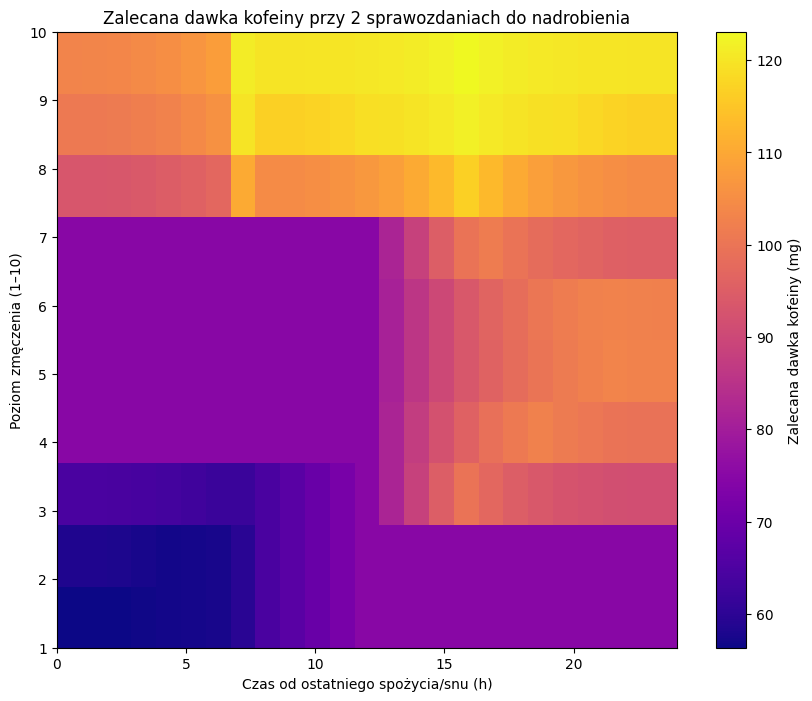

In [39]:
for i, x in enumerate(ostatnia_sesja):
    for j, y in enumerate(poziom_zmeczenia):
        ilosc_kofeiny.input['czas_od_spoczynku'] = x
        ilosc_kofeiny.input['poziom_zmeczenia'] = y
        ilosc_kofeiny.input['ilosc_sprawozdan'] = 2
        ilosc_kofeiny.compute()
        heatmap[i, j] = ilosc_kofeiny.output['kofeina']


plt.figure(figsize=(10, 8))
plt.imshow(heatmap.T, origin='lower', extent=[0, 24, 1, 10], aspect='auto', cmap='plasma')
plt.colorbar(label='Zalecana dawka kofeiny (mg)')
plt.xlabel('Czas od ostatniego spożycia/snu (h)')
plt.ylabel('Poziom zmęczenia (1–10)')
plt.title('Zalecana dawka kofeiny przy 2 sprawozdaniach do nadrobienia')
plt.show()

Heatmapa rezultatów prezentuje się bardzo poprawnie. Można zauważyć, że przejścia pomiędzy stanami są płynne, zauważamy skrajności kiedy wymagana dawka kofeiny jest bardzo wysoka bądź bardzo niska. Wskazuje to na poprawnie dobrane funkcje przynależności. Mimo to można zauważyć pewne problemy. Przy poziomie zmęczenia 3, można zauważyć, że dla czasu równego 16h, zalecana dawka to około 100mg, natomiast dla 24h zaledwie 90mg. Jest to oczywsity błąd i niedopasowanie, wynikające najprawdopodobniej z zbyt małej oraz zbyt dokładnej ilości reguł. W sytuacji w której badanie przeprowadzane jest na 3 danych wejściowych, liczba reguł powinna wynosić 27 ( 3^3 ). W tym badaniu zastosowano mniej reguł, oraz zastosowano uproszczenie w celu wypełnienia heatmapy, tzn. reguła 15 mówi że dla dowolnego czasu, dawka kofeiny to puszka redbulla ( do śniadania nikomu jeszcze nie zaszkodziła ). To wypełnienie powoduje pojedyńcze luki / błędy / nieścislości, lecz mimo to, całe badanie przebiegło pomyślnie. Oczywiście heatmapa wygenerowana dla 2 zaległych sprawozdań sprawiła że większość wyników oscyluje w granicy 0 - 90mg.

Ilość sprawozdań = 4

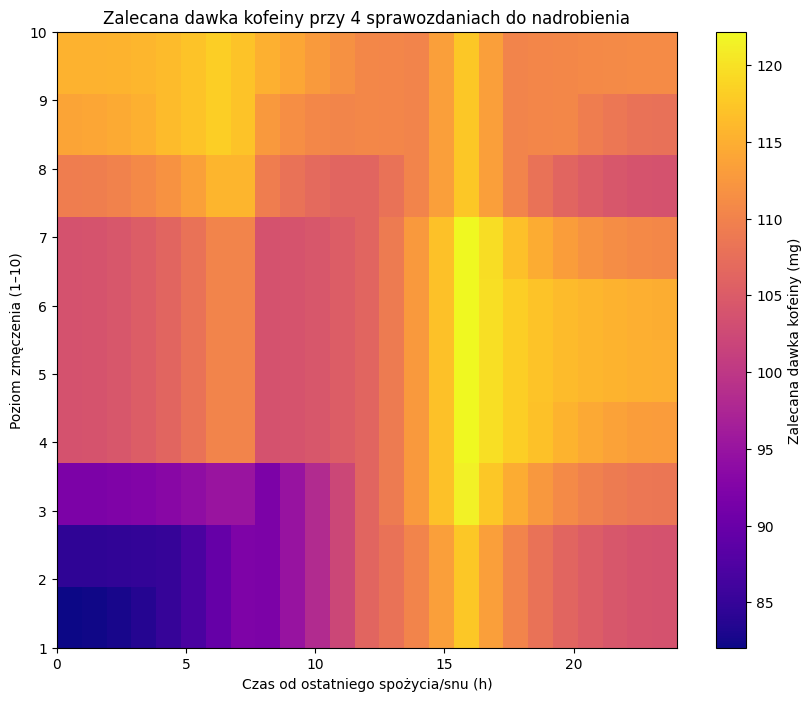

In [38]:
for i, x in enumerate(ostatnia_sesja):
    for j, y in enumerate(poziom_zmeczenia):
        ilosc_kofeiny.input['czas_od_spoczynku'] = x
        ilosc_kofeiny.input['poziom_zmeczenia'] = y
        ilosc_kofeiny.input['ilosc_sprawozdan'] = 4
        ilosc_kofeiny.compute()
        heatmap[i, j] = ilosc_kofeiny.output['kofeina']

plt.figure(figsize=(10, 8))
plt.imshow(heatmap.T, origin='lower', extent=[0, 24, 1, 10], aspect='auto', cmap='plasma')
plt.colorbar(label='Zalecana dawka kofeiny (mg)')
plt.xlabel('Czas od ostatniego spożycia/snu (h)')
plt.ylabel('Poziom zmęczenia (1–10)')
plt.title('Zalecana dawka kofeiny przy 4 sprawozdaniach do nadrobienia')
plt.show()

Badanie przeprowadzone dla ilości zaległych sprawozdań równej 4, wskazuje na bardzo duży wzrost pod kątem zakresów zalecanej dawki kofeiny. W tym przypadku około 70% wartości, stanowią te z przedziału 105mg - 200mg zalecanej dawki kofeiny.

Zauważono pewien problem, to znaczy wartości zalecanej dawki są największe przy poziomie zmęczenia 5/6 podczas czasu od ostatniego spoczynku 23h, natomiast spadają dla poziomu zmęczenia 9 / 10. Wynika to najprawdopodobniej z źle dobranych reguł połączonych z tą ilością zaległych sprawozdań. Przy dużej ilości danych wejściowych warto zastosować inny mechanizm dotyczący wyznaczania reguł, ponieważ już dla 5 danych wejściowych, co w sytuacji rzeczywistej wcale nie jest dużą liczbą, ilość wymaganych reguł to 5^5 = 3125 reguł. Pisanie ich ręcznie nie ma prawa powodzenia badania.

Widoki dla danych wejsciowych

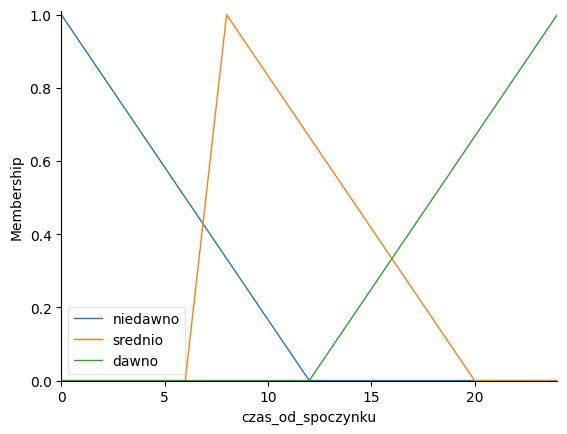

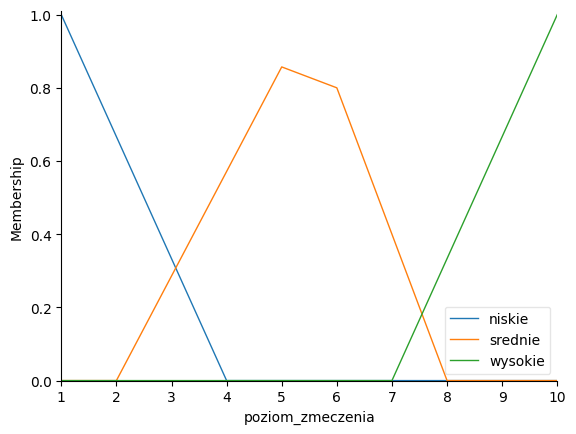

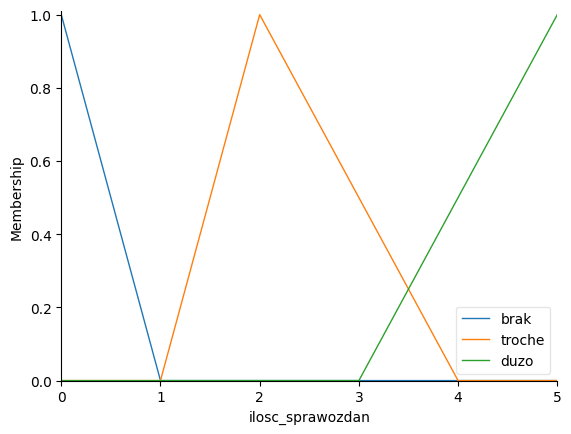

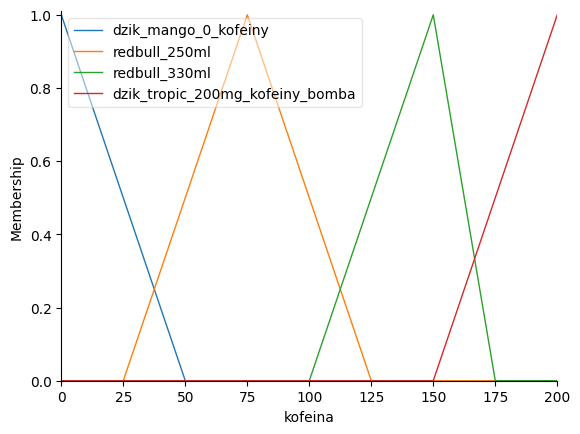

In [37]:
czas.view()
zmeczenie.view()
sprawozdania.view()
kofeina.view()

Na koniec można zwrócić uwagę na funkcję przynależności. Kluczowym aspektem badania jest to, aby miały one punkty wspólne. Tak też się stało, czego dowodem jest poziom zmęczenia z zakresu 2 - 4. Wtedy wartości subiektywne wahają się od niskiego do średniego poziomu zmęczenia. Gdy zwrócimy uwagę na pierwszą heatmapę, zauważamy że dla tych wartości oraz czasu od ostatniego snu powyżej 12h następuje płynne przejście pomiędzy wartościami co wskazuje na poprawność ułożonej funkcji przynależności